In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Sales dataset Cleaning: Handling Missing Values, Invalid Data, Duplicates and Standardization

sales = pd.read_csv('../data/sales_messy.csv')
sales = sales[sales['Quantity']>0]
sales['Price'] = sales['Price'].replace(0,np.nan)
sales.loc[sales['Price']<0,'Price'] = np.nan
sales['Price']=sales.groupby('Product')['Price'].transform('mean').fillna(sales['Price'])
sales = sales.dropna(subset=['Region'])
sales['Region'] = sales['Region'].str.title()
sales = sales.drop_duplicates()
sales.duplicated().sum()
sales.shape
sales.isna().sum()
sales.to_csv('../data/sales_cleaned.csv',index=False)


In [ ]:
# data = pd.read_csv('../data/sales_cleaned.csv')
# date_range = pd.date_range(start='2025-01-01',end='2025-12-31')
# data['Date'] = np.random.choice(date_range,size = len(data))
# data.to_csv('../data/sales_cleaned.csv',index=False)

In [ ]:
# Starting of the Analysis as well as Feature Engineering

data = pd.read_csv('../data/sales_cleaned.csv')
data.describe()
data['Revenue'] = data['Price']*data['Quantity']
total_revenue = data['Revenue'].sum()
print(total_revenue)

# Finding average revenue per order

avg_revenue_per_order = round(data['Revenue'].mean(),1)
print(avg_revenue_per_order)

525795000.0
100246.9


Region
West     134039000.0
East     133320000.0
North    130151000.0
South    128285000.0
Name: Revenue, dtype: float64


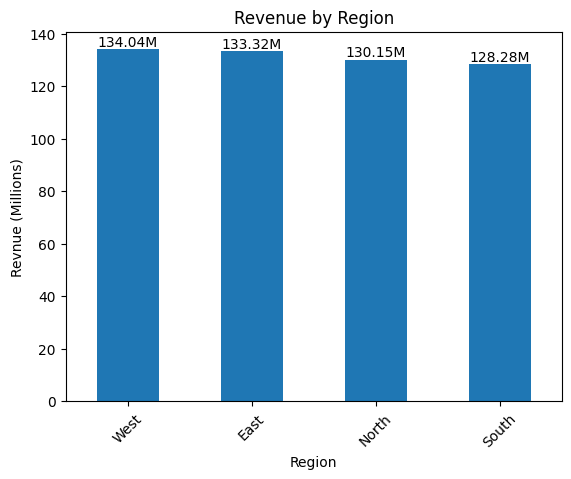

In [163]:
# Finding revenue by region
region_revenue = data.groupby('Region')['Revenue'].sum().sort_values(ascending=False) 
print(region_revenue)
region_revenue_millions = region_revenue/1e6
ax=region_revenue_millions.plot(kind = 'bar', title = 'Revenue by Region', ylabel = 'Revnue (Millions)', rot = 45)
ax.bar_label(ax.containers[0], fmt='%.2fM')
plt.show()
#West region generates the highest revenue, indicating the strong sales performance in that region.South region contributes the least suggesting the potential for growth or lower demand compared to other region.Overall, revenue distribution across regions is exactly balanced with no extreme gaps

Category
Electronics    474010000.0
Fashion         51785000.0
Name: Revenue, dtype: float64


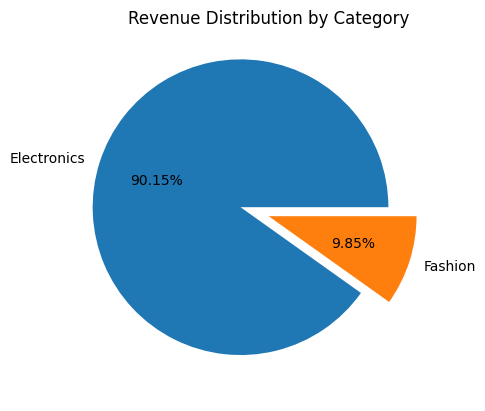

In [68]:
# Finding which category of the product generates more revenue

category_revenue = data.groupby('Category')['Revenue'].sum().sort_values(ascending=False)
print(category_revenue)

ax = category_revenue.plot(kind='pie', title = 'Revenue Distribution by Category',explode=[0.2,0], autopct = '%.2f%%')
plt.show()
#Electronics generate higher revenue compared to Fashion due to their higher unit price. Even with similar or lower quantities sold, high value products like laptops and tablets contribute more to the total revenue. This indicates that total revenue is heavily influenced by the product price rather than just sales volume.

Product
Laptop    255090000.0
Tablet    128160000.0
Mobile     90760000.0
Watch      21835000.0
Jacket     16612000.0
Shoes      13338000.0
Name: Revenue, dtype: float64


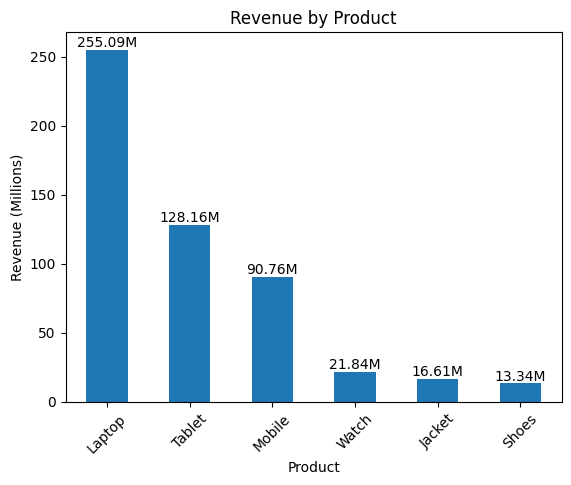

In [166]:
# Finding top 5 products (Highest Revenue) and the lowest revenue product

top_revenue_products = data.groupby('Product')['Revenue'].sum().sort_values(ascending=False)
print(top_revenue_products)

top_revenue_products_millions = top_revenue_products/1e6
ax = top_revenue_products_millions.plot(kind = 'bar', title='Revenue by Product', ylabel='Revenue (Millions)', rot=45)
ax.bar_label(ax.containers[0], fmt='%.2fM')
plt.show()

#High-priced products like laptops and tablets generates the most revenue, indicating that price paly a significant role in revenue contribution. Lower-priced products like shoes generate the least revenue despite the high sales volume, highlighting the combines effect of both price and quantity.

In [ ]:
# Checking infulence of price and quantity on revenue

data.groupby('Category')[['Revenue','Quantity']].sum()

#In this dataset, price has a stronger influence on the revenue than quantity. Despite similar sales volumes between electronics (13,448 units) and Fashion (12,966 units), Electronics generates significantly higher revenue (47.4 cr) compared to Fashion (5.17 cr). This indicates the high_price products dominate revenue contribution, making the business more dependent on pricing than volume.

,Revenue,Quantity
Category,,
Electronics,474010000.0,13448.0
Fashion,51785000.0,12966.0


In [41]:
# Converting the date datatype to datetime to derive useful insights.

data['Date'] = pd.to_datetime(data['Date'])
data['Month'] = data['Date'].dt.month_name()
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
data['Month'] = pd.Categorical(data['Month'], categories =month_order, ordered = True)
data['Quarter'] = 'Q'+ data['Date'].dt.quarter.astype(str)
quarter_order = ['Q1','Q2','Q3','Q4']
data['Quarter'] = pd.Categorical(data['Quarter'],categories=quarter_order, ordered=True)

Month
January      48698000.0
February     40325000.0
March        41619000.0
April        47912000.0
May          43649000.0
June         38869000.0
July         44756000.0
August       44928000.0
September    42465000.0
October      43976000.0
November     42225000.0
December     46373000.0
Name: Revenue, dtype: float64


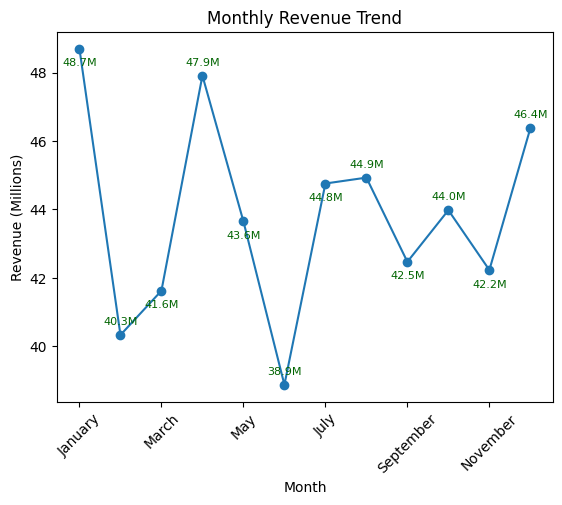

In [120]:
# Finding revenue by month

monthly_revenue = data.groupby('Month')['Revenue'].sum()
print(monthly_revenue)

monthly_revenue_millions = monthly_revenue/1e6
ax = monthly_revenue_millions.plot(kind='line',title='Monthly Revenue Trend', marker='o',rot=45,ylabel='Revenue (Millions)')
for x, y in enumerate(monthly_revenue_millions.values):
    offset = -0.5 if x%2==0 else 0.3
    ax.text(x, y+offset, f'{y:.1f}M', ha='center', fontsize=8, color='darkgreen')
plt.show()

In [35]:
# Finding top region per product

top_region_per_product = data.groupby(['Product','Region'])['Revenue'].sum().unstack()
top_region_per_product

Region,East,North,South,West
Product,,,,
Jacket,4140000.0,4320000.0,3808000.0,4344000.0
Laptop,65505000.0,62370000.0,60115000.0,67100000.0
Mobile,22640000.0,22820000.0,22260000.0,23040000.0
Shoes,3270000.0,3366000.0,3327000.0,3375000.0
Tablet,32310000.0,32160000.0,33240000.0,30450000.0
Watch,5455000.0,5115000.0,5535000.0,5730000.0


Category   Electronics  Fashion
Month                          
January         44.035    4.663
February        36.275    4.050
March           36.810    4.809
April           43.675    4.237
May             39.435    4.214
June            34.895    3.974
July            40.600    4.156
August          40.695    4.233
September       38.290    4.175
October         39.195    4.781
November        37.730    4.495
December        42.375    3.998


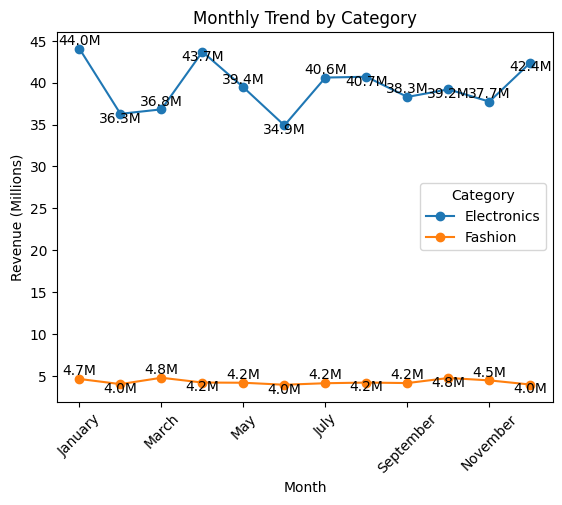

In [140]:
# Finding  monthly trend by category

temp=data.groupby(['Month','Category'])['Revenue'].sum().unstack()/1e6
print(temp)
ax = temp.plot(kind='line', title='Monthly Trend by Category', marker='o', ylabel='Revenue (Millions)', rot=45)
for col in temp.columns:
    for x,y in enumerate(temp[col].values):
        offset = 0.5 if x%2==0 else -1
        ax.text(x,y+offset,f'{y:.1f}M',ha='center')
plt.show()

Quarter
Q1    130642000.0
Q2    130430000.0
Q3    132149000.0
Q4    132574000.0
Name: Revenue, dtype: float64


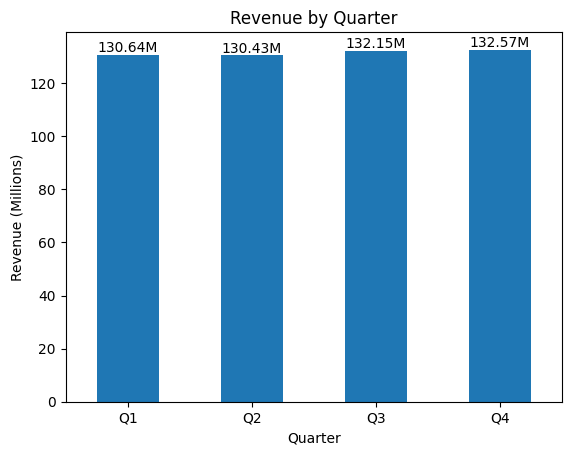

In [159]:
# Finding revenue by quarter

quarterly_revenue = data.groupby('Quarter')['Revenue'].sum()
print(quarterly_revenue)
quarterly_revenue_millions = quarterly_revenue/1e6

ax = quarterly_revenue_millions.plot(kind='bar',title='Revenue by Quarter',ylabel='Revenue (Millions)',rot=0)
ax.bar_label(ax.containers[0],fmt='%.2fM')
plt.show()

In [ ]:
# Business Recommendation

'''
-> Focus on promoting high-value products like laptops and tablets as they drive maximum revenue.
-> Improve sales startegies in the South region to increase its contribution.
-> Maintain strong performance in the West region through targeted marketing.
-> Intoduce pricing or marketing strategies for low-performing products like shoes.

'''

In [ ]:
# KPI Summary

'''
Key Metrics:
            -> Total Revenue: 525M+ Rupees
            -> Average Revenue per Oreder: ~1Lac Rupees
            -> Top Region: West
            -> Top Product: Laptop
'''
